In [12]:
import sys
sys.path.append('../src')

In [13]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from stock_prices import get_stock_prices, plot_stock_prices, split_train_test
from feature_extraction import add_state_column
from technical_indicator_classifier import TechnicalIndicatorClassifier
from hybrid_model import HybridModel
from simulation import simulate_trade

In [223]:
symbol = "^GSPC"
start_date = "2023-01-01"
split_date = "2024-12-31"
end_date = "2025-12-31"

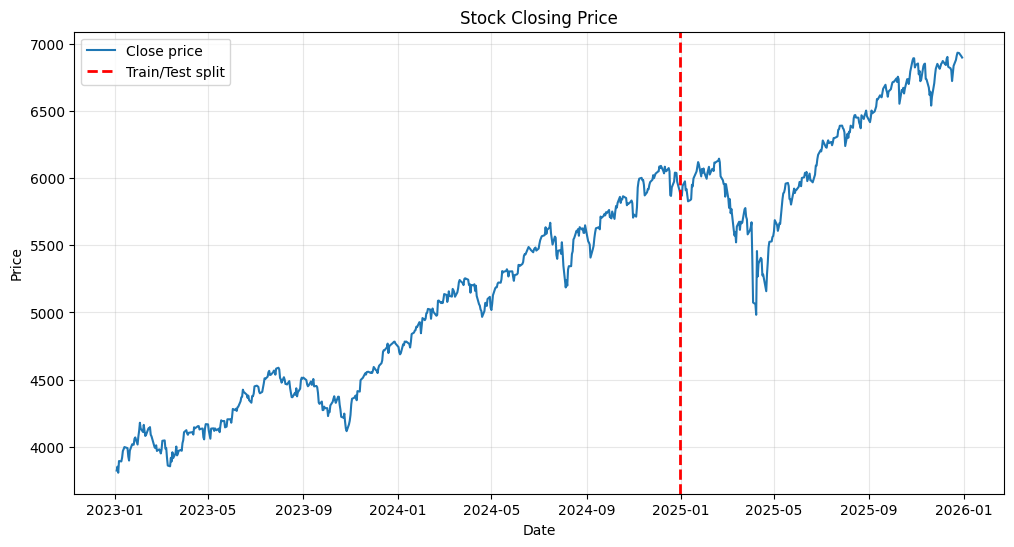

,symbol,date,open,high,low,close,volume,dividends,stock_splits
0,^GSPC,2023-01-03,3853.290039,3878.459961,3794.330078,3824.139893,3959140000,0.0,0.0
1,^GSPC,2023-01-04,3840.360107,3873.159912,3815.770020,3852.969971,4414080000,0.0,0.0
2,^GSPC,2023-01-05,3839.739990,3839.739990,3802.419922,3808.100098,3893450000,0.0,0.0
3,^GSPC,2023-01-06,3823.370117,3906.189941,3809.560059,3895.080078,3923560000,0.0,0.0
4,^GSPC,2023-01-09,3910.820068,3950.570068,3890.419922,3892.090088,4311770000,0.0,0.0


In [224]:
stock_prices = get_stock_prices(symbol, start_date, end_date)
plot_stock_prices(stock_prices, split_date)
stock_prices.head()

In [225]:
add_state_column(stock_prices)
stock_prices_train, stock_prices_test = split_train_test(stock_prices, split_date)

In [226]:
method = "GaussianNB"
peek = 3
k = 6

In [227]:
classifier = TechnicalIndicatorClassifier(model = method, peek = peek)
classifier.train(stock_prices_train)

In [228]:
np.random.seed(5)
hybrid_model = HybridModel(k = k, classifier = classifier)
hybrid_model.train(stock_prices_train)

Epoch 301: Total reward = 0.17, Past Ten Total Rewards Std = 0.04493603568160039
Model stabilizes at epoch 301


True

Accumulated returns on training data:
Buy and hold return:  0.4290331009151267


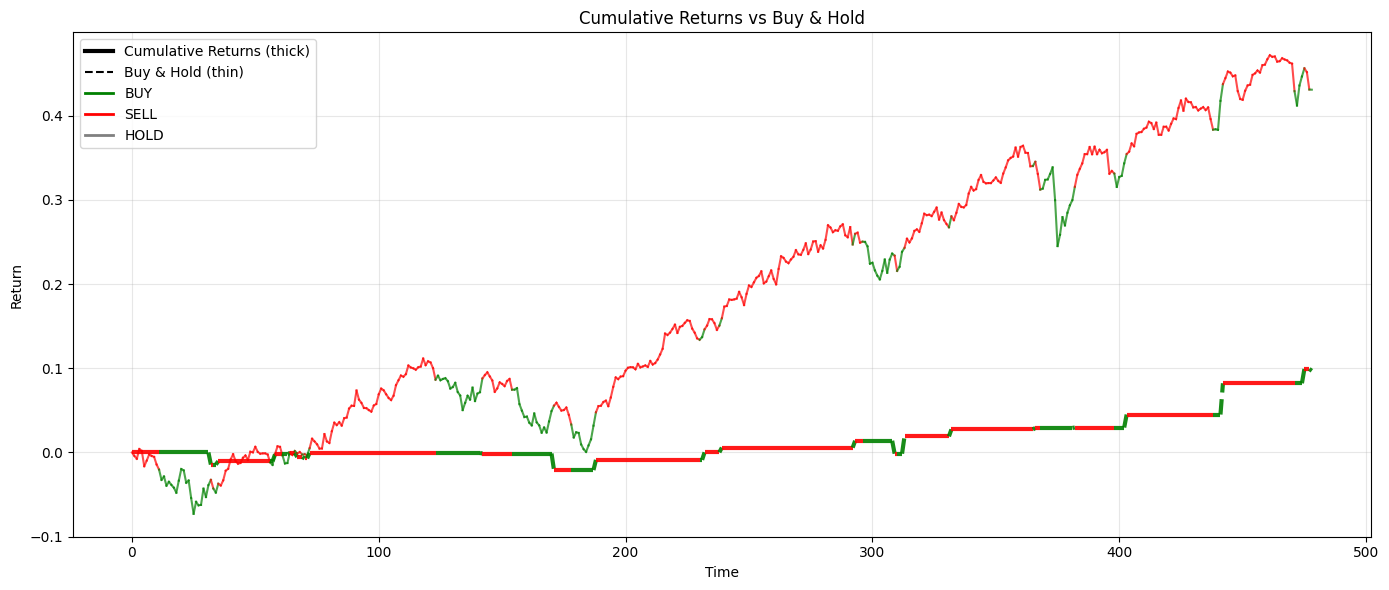

MA based return: 0.0970186953330554


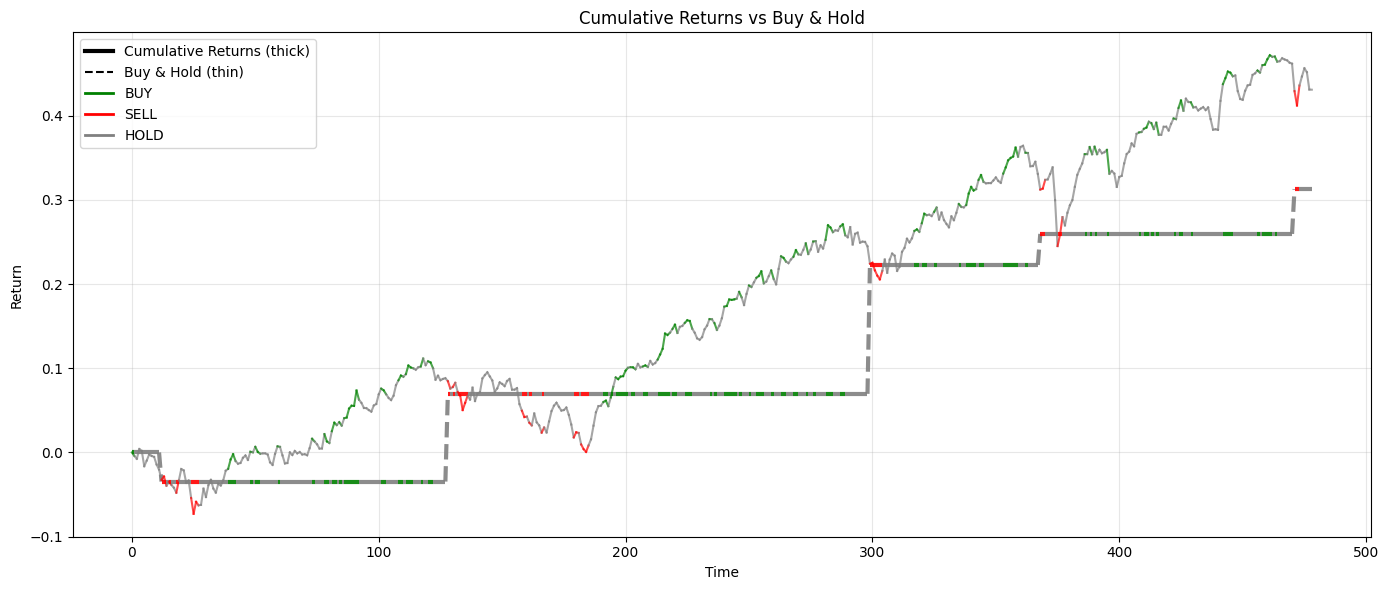

Breakout based return: 0.3129849091434187


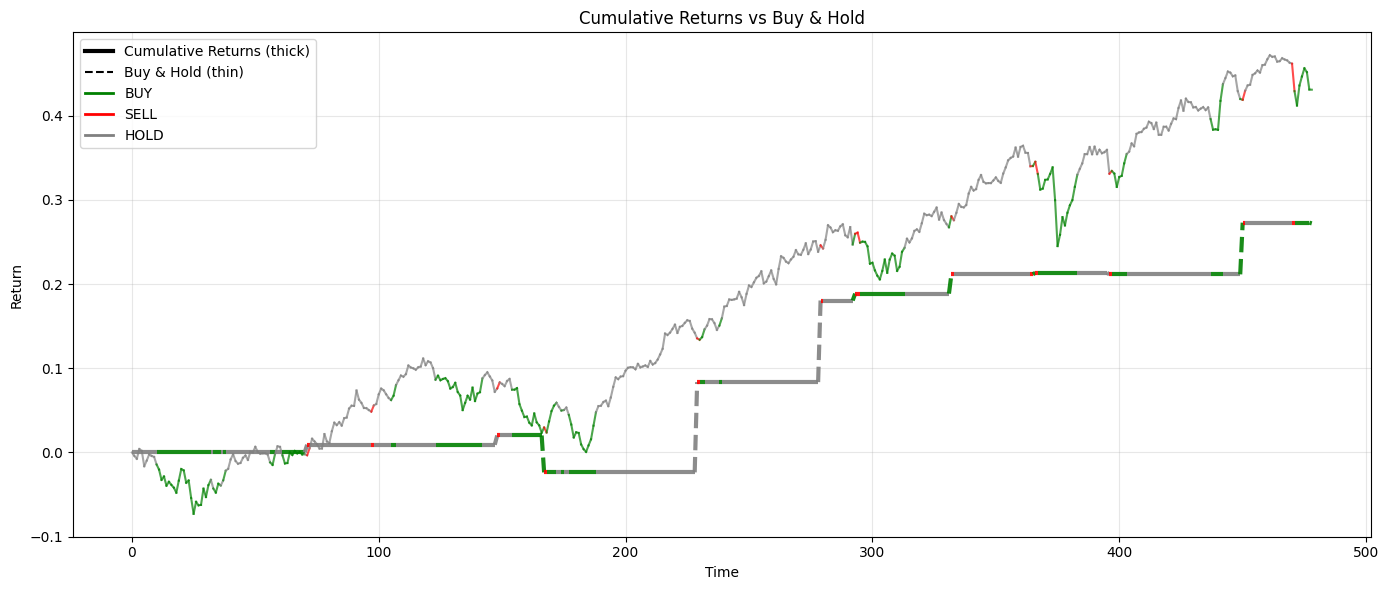

Classifier model return: 0.27220370123160986


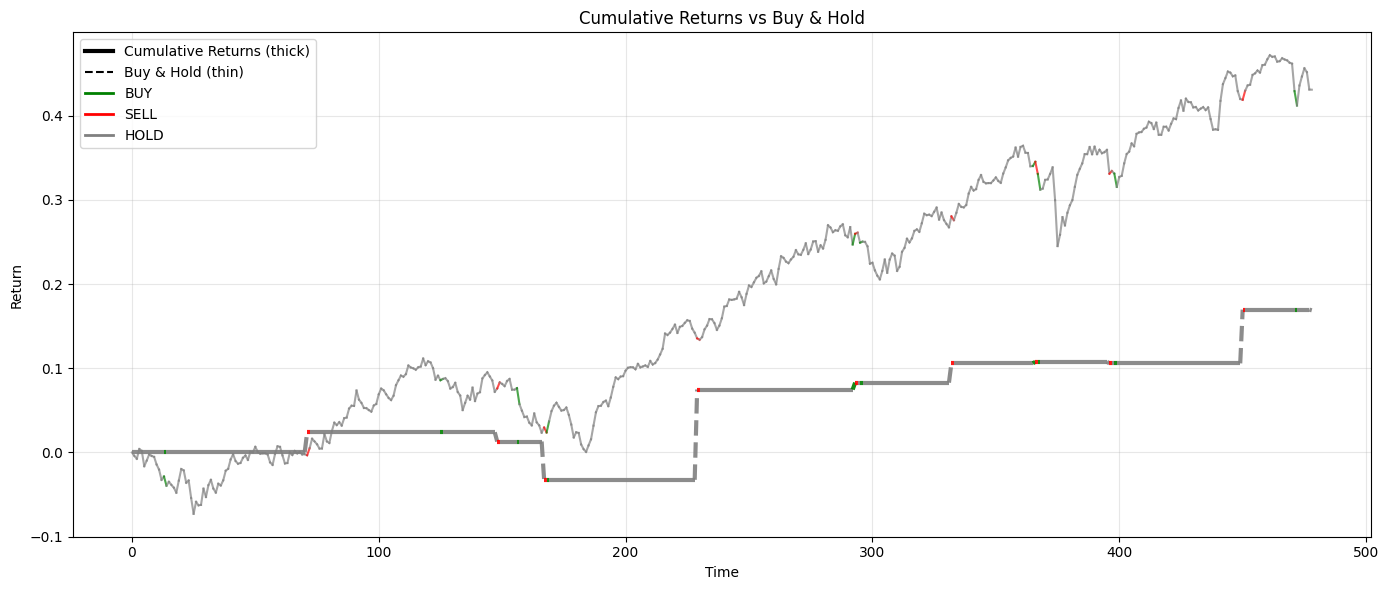

Hybrid model return: 0.16888545060474575


In [229]:
train_result = {}
print("Accumulated returns on training data:")
open_prices_train = stock_prices_train["open"].values[20:]

train_result["buy and hold"] = (open_prices_train[-1] / open_prices_train[1] - 1.002)
print("Buy and hold return: ", train_result["buy and hold"])

train_result["ma"] = simulate_trade(stock_prices_train, "ma", plot = True)
print("MA based return:", train_result["ma"])

train_result["breakout"] = simulate_trade(stock_prices_train, "breakout", plot = True)
print("Breakout based return:", train_result["breakout"])

train_result["classifier"] = simulate_trade(stock_prices_train, classifier, plot = True)
print("Classifier model return:", train_result["classifier"])

if k != 0:
    train_result["hybrid"] = simulate_trade(stock_prices_train, hybrid_model, plot = True)
    print("Hybrid model return:", train_result["hybrid"])

Accumulated returns on test data:
Buy and hold return:  0.1693390177515608


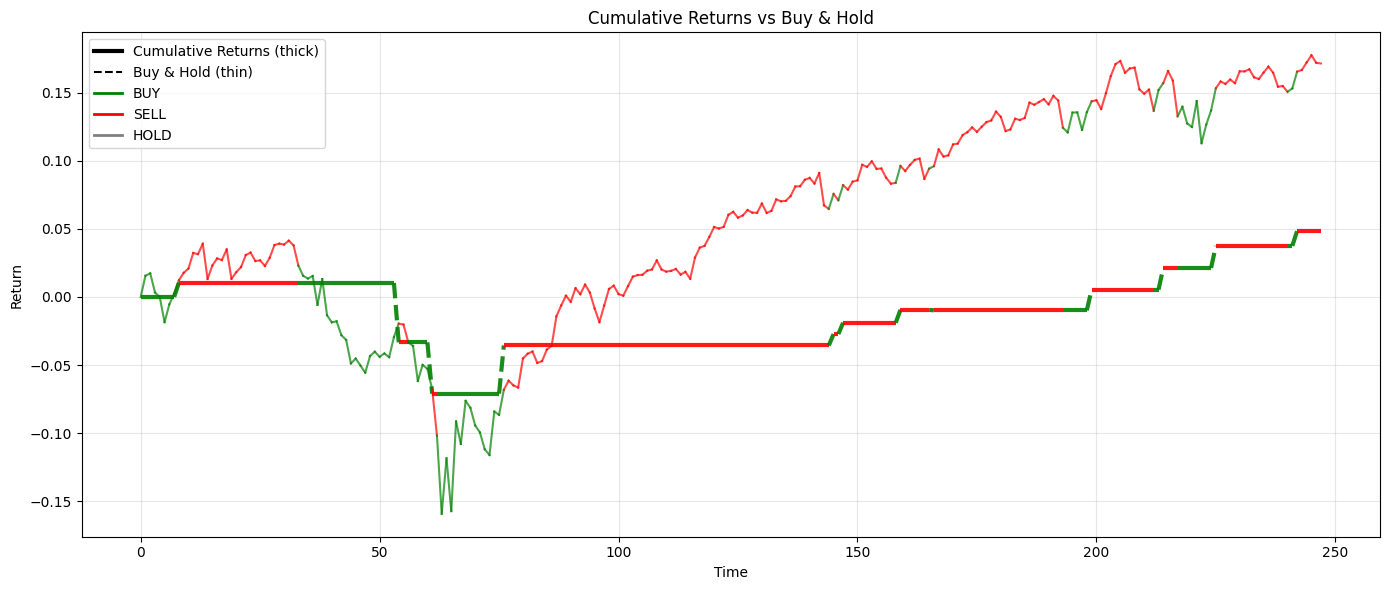

MA only return: 0.048339859824709605


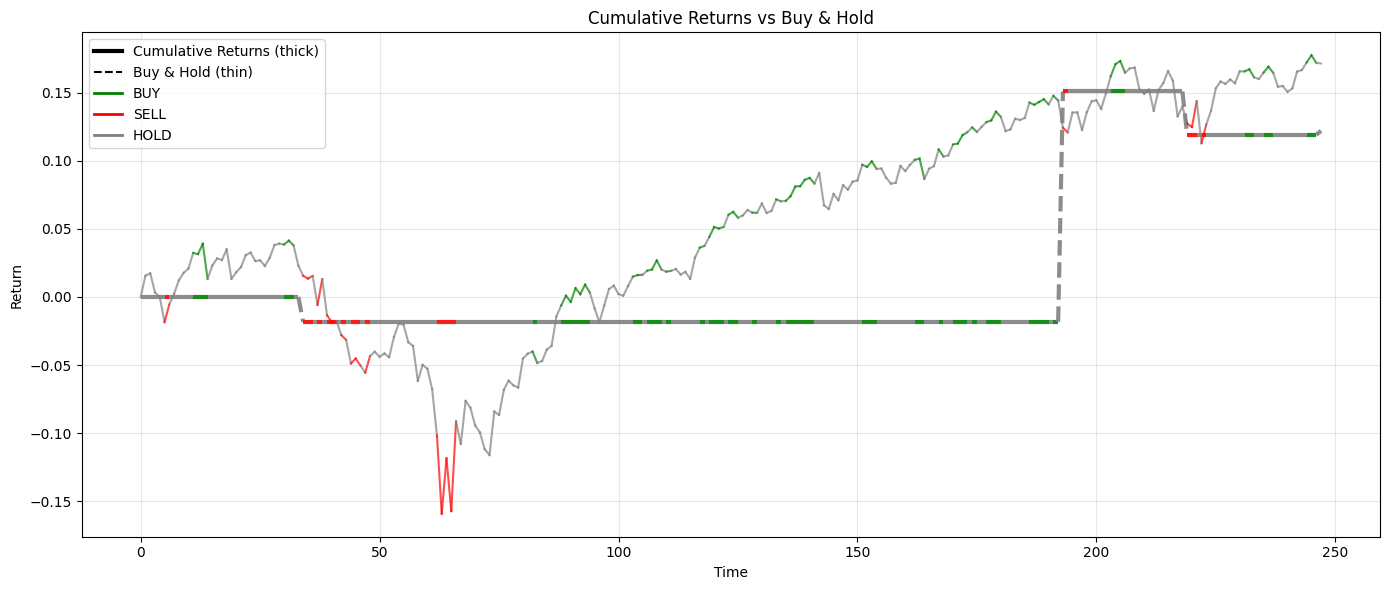

Breakout based return: 0.1219322633564154


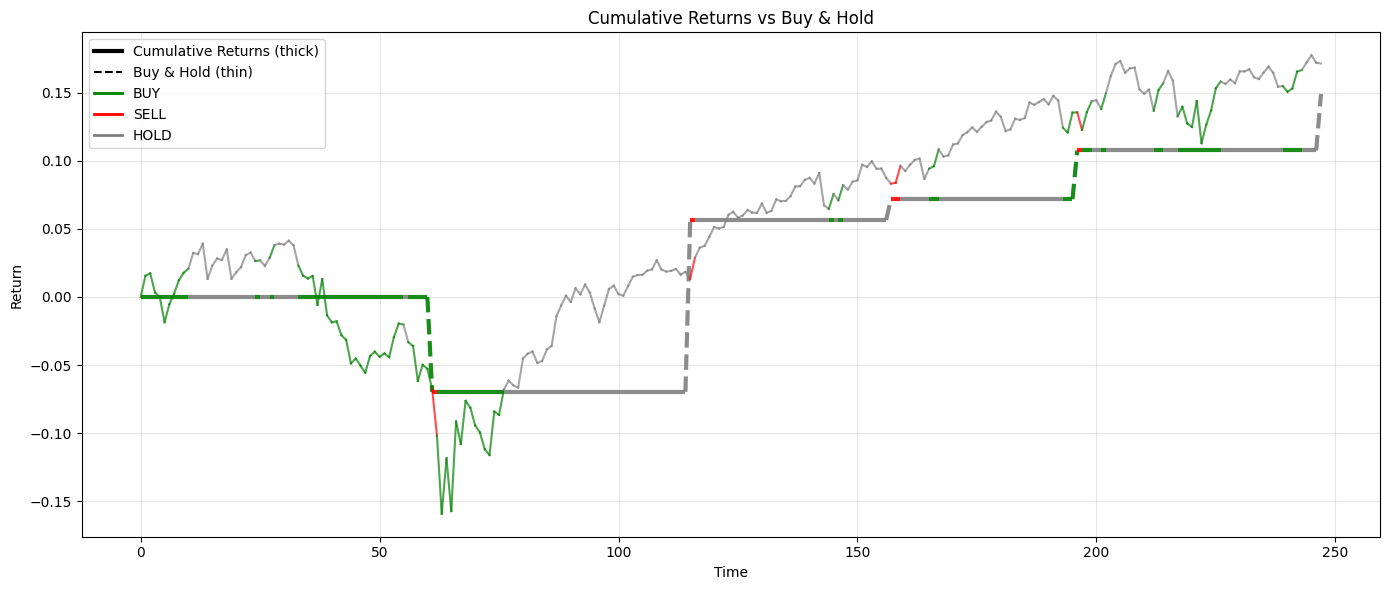

Classifier model return: 0.14896181571504472


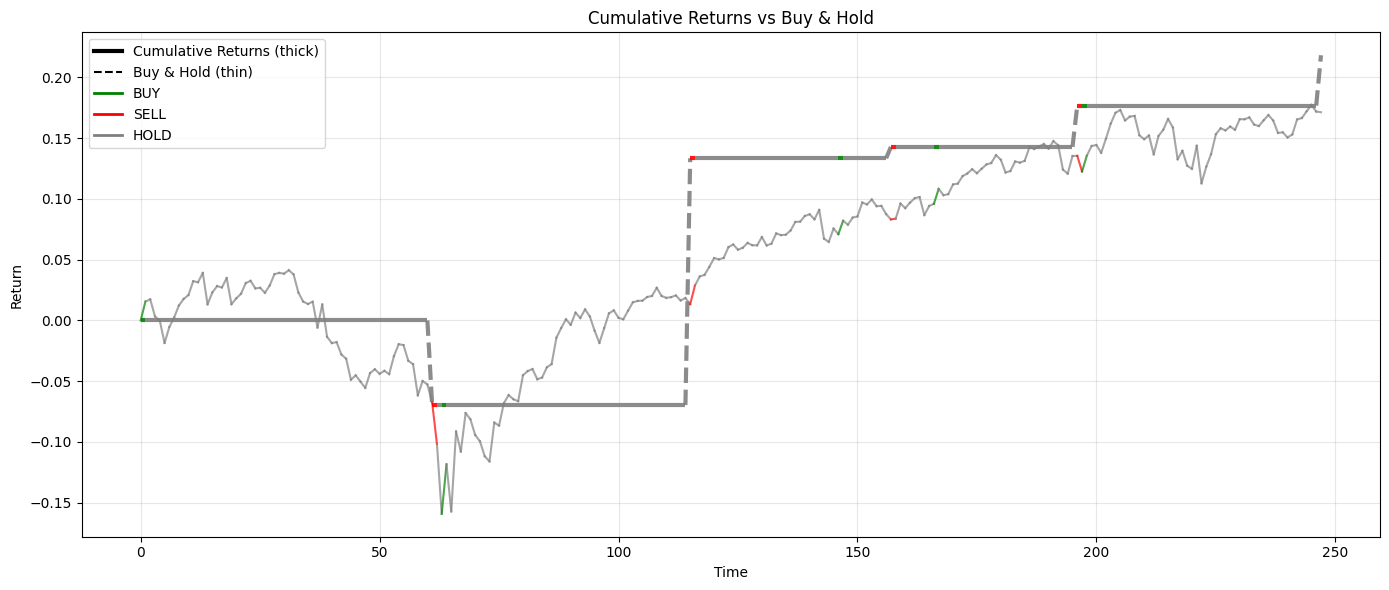

Hybrid model return: 0.2182132354628263


In [230]:
test_result = {}
print("Accumulated returns on test data:")
open_prices_test = stock_prices_test["open"].values[20:]

test_result["buy and hold"] = (open_prices_test[-1] / open_prices_test[1] - 1.002)
print("Buy and hold return: ", test_result["buy and hold"])

test_result["ma"] = simulate_trade(stock_prices_test, "ma", plot = True)
print("MA only return:", test_result["ma"])

test_result["breakout"] = simulate_trade(stock_prices_test, "breakout", plot = True)
print("Breakout based return:", test_result["breakout"])

test_result["classifier"] = simulate_trade(stock_prices_test, classifier, plot = True)
print("Classifier model return:", test_result["classifier"])

if k != 0:
    test_result["hybrid"] = simulate_trade(stock_prices_test, hybrid_model, plot = True)
    print("Hybrid model return:", test_result["hybrid"])

In [231]:
def run_iteration(i):
    np.random.seed(i)
    hybrid_model = HybridModel(k = k, classifier = classifier)
    stable = hybrid_model.train(stock_prices_train, show_log = False)
    trial = 1
    while not stable:
        stable = hybrid_model.train(stock_prices_train, show_log = False)
        trial += 1
        if trial == 10:
            print(f"Model failed to stabilize even after 10 trials (seed {i})")
            # Only account instance which achieves pseudo-convergence before max epochs
            return None
    test_ret = simulate_trade(stock_prices_test, hybrid_model, plot = False)
    return test_ret

results = Parallel(n_jobs = -1)(delayed(run_iteration)(i) for i in range(6, 21))
results = [result for result in results if result is not None]
hybrid_returns = np.array(results)

buy_hold_return = test_result["buy and hold"]

ma_return = test_result["ma"]
excess_ma = ma_return - buy_hold_return

break_out_return = test_result["breakout"]
excess_momentum = break_out_return - buy_hold_return

classifier_return = test_result["classifier"]
excess_classifier = classifier_return - buy_hold_return

mean_hybrid_return = np.mean(hybrid_returns)
hybrid_excess_returns = hybrid_returns - buy_hold_return
excess_hybrid = mean_hybrid_return - buy_hold_return
excess_hybrid_std =  np.std(hybrid_excess_returns)

# Create dataframe with 8 columns
results_df = pd.DataFrame({
    'Buy and Hold': [buy_hold_return],
    'MA Based': [ma_return],
    'Breakout Based': [break_out_return],
    'Classifier Model': [classifier_return],
    'Mean Hybrid Model': [mean_hybrid_return],
    'Excess MA': [excess_ma],
    'Excess Breakout': [excess_momentum],
    'Excess Classifier': [excess_classifier],
    'Excess Hybrid': [excess_hybrid],
    'Excess Hybrid Std': [excess_hybrid_std],
    'Number of Samples': len(hybrid_returns)
})

display(results_df)

results_df.to_parquet(f"results/{symbol[:4]}.parquet", engine = "pyarrow")

,Buy and Hold,MA Based,Breakout Based,Classifier Model,Mean Hybrid Model,Excess MA,Excess Breakout,Excess Classifier,Excess Hybrid,Excess Hybrid Std,Number of Samples
0,0.169339,0.04834,0.121932,0.148962,0.20786,-0.120999,-0.047407,-0.020377,0.038521,0.032451,15
